In [40]:
#Generate csv file for average time
#Branch33-01
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/Users/dinguyen/Desktop/Local Documents/GitHub/Paper5/PythonConversion/")
N = 50

# N30	
# ins = [1,2,5,6,7,8,9,10,11,12]
# ins = [4,20,83,99,107,166,172,174,200,241]
# ins = [3,35,36,37,52,63,64,150, 282,319]
# ins = [1,2,5,6,7,8,9,10,11,12,4,20,83,99,107,166,172,174,200,241,3,35,36,37,52,63,64,150, 282,319]


# N40	
# ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# ins =  [4, 8, 16, 27, 33, 36, 37, 48, 64, 68]
# ins =  [2, 14, 18, 22, 24, 38, 39, 40, 56, 76]
# ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13,4, 8, 16, 27, 33, 36, 37, 48, 64, 68,2, 14, 18, 22, 24, 38, 39, 40, 56, 76]


# N50	
# ins =  [2, 6, 7, 10, 13, 14, 15, 16, 17, 21]
# ins =  [18, 26, 46, 73, 93, 98, 110, 113, 122, 124]
# ins =  [1, 3, 4, 5, 8, 9, 11, 12, 19, 20]
ins =  [2, 6, 7, 10, 13, 14, 15, 16, 17, 21,18, 26, 46, 73, 93, 98, 110, 113, 122, 124,1, 3, 4, 5, 8, 9, 11, 12, 19, 20]

def processMain(N, ins):
    fileNames = []
    for i in ins:
        fileNames.append("./Dec2024_Output/Iter/main_15_N"+str(N)+"_"+str(i)+".txt")
        # fileNames.append("./Iter/main_A3_0_15_N"+str(N)+"_"+str(i)+".txt")
    # print(fileNames)
    # Use the next line for finished ins
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A3_0_15_N"+str(N)+"_")]
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A2_1_15_N"+str(N)+"_")]
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in fileNames:
        # print(filename)
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        try: 
            num_rows = sum(1 for line in open(filename))
            
            df = pd.read_csv(''+filename, sep=';', names=['Status','iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K'], header=None)
            # Use the one below for Iter collection
            # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
            idx = df.index[df['iiter'] == 1].max()
            print(idx)
            df = df[idx:]
            df['Ins'] = split
            df['Ins'] = df['Ins'].astype(int)
            df["elapsedT"] = df['total_time'].diff(-1).abs()
            df = df.iloc[:-1]
            dfs_list.append(df)
        except:
            print("File "+filename+" does not exist.")
        # print(df)
    df_filtered = pd.concat(dfs_list, axis=0, ignore_index=True)
    
    # df_filtered['max'] = df_filtered.groupby('Ins')['iiter'].transform('max')
    
    # df_filtered = df_filtered[~df_filtered['Ins'].isin(ins_not_terminate)]
    # df_filtered = df_filtered.groupby('Ins').apply(
    #     lambda group: group[group['total_time'] == group['total_time'].max()])
    # df_filtered = df_filtered.reset_index(drop=True)
    df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100
    
    print("Average Sol Time ", df_filtered['total_time'].mean())
    print("Average |K| ", df_filtered['K'].mean())
    print("Average Opt Gap ", df_filtered["OptGap"].mean(),"%")
    print("Average Iter", df_filtered["iiter"].mean()+1)
    print("Number of solved ins ", len(df_filtered))
    
    

    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return df_filtered

df_default = processMain(N,ins)
df_default
df_default.to_csv('N'+str(N)+'_timeperitervscell.csv', index=False)
# df_default[(df_default.total_time >= 300) &(df_default.total_time <= 3600)]
# df_default[(df_default.total_time < 300)]
# print(list(df_default[(df_default.total_time >= 300) &(df_default.total_time <= 3600)]['Ins']))

40
20
12
28
5
5
36
26
5
7
0
78
59
70
0
0
0
0
0
0
26
81
29
30
84
31
27
42
21
25
Average Sol Time  89.06501654766757
Average |K|  364.9396551724138
Average Opt Gap  45.16002238947147 %
Average Iter 12.125
Number of solved ins  464


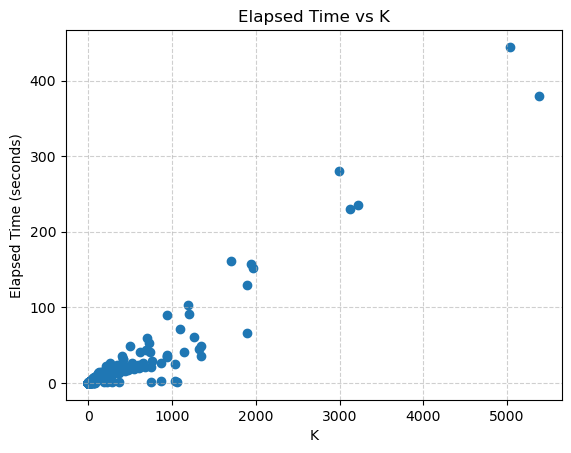

In [34]:
# Create scatter plot
plt.scatter(df_default['K'], df_default['elapsedT'])

# Add labels and title
plt.xlabel('K')
plt.ylabel('Elapsed Time (seconds)')
plt.title('Elapsed Time vs K')

# Optional: grid and nicer markers
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()